In [2]:
%matplotlib inline
import os
import sys
from os.path import join as pjoin
from tifffile import imread, imwrite, TiffFile
import numpy as np
import shutil
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import cv2
from tqdm import tqdm
import subprocess
from scipy.ndimage import gaussian_filter,median_filter

project_root = '/home/lsh/WF_GoNogo'
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.wfield_utils import *

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import cupy as cp
cp._default_memory_pool.free_all_blocks()

Experiments found: ['20250906-185140']
Merged 20250906-185140 already exists


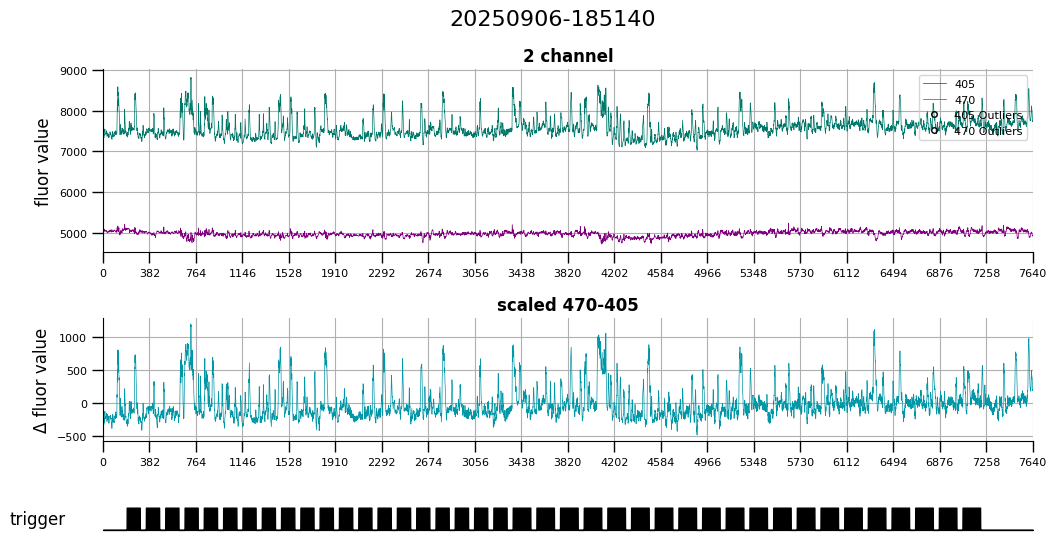

Finished merging for single day.


In [4]:
%matplotlib inline
def filename2int(filename):
    import re
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1

def organize_tif(folder_path, processPath):
    folder_name = os.path.basename(folder_path)
    tif_path = folder_path + '.tif'
    if os.path.exists(tif_path):
        print(f'importing {tif_path}')
        image_stack = imread(tif_path)
        print(f'finish importing {tif_path}')
    else:
        image_path_ls = glob(os.path.join(folder_path, '*.tif'))
        image_path_ls = sorted(image_path_ls, key=filename2int)
        image_stack = [imread(tiff) for tiff in image_path_ls]
    mean_values = [np.mean(frame) for frame in image_stack]
    output_value = os.path.join(processPath, folder_name + "-Values.csv")
    np.savetxt(output_value, mean_values, delimiter=",")
    return np.array(image_stack)

def merge_two_channels(rawPath, processPath, experiment):
    os.makedirs(os.path.join(processPath, experiment + "-wfield"), exist_ok=True)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_file = os.path.join(mergePath, experiment + "-merged.tif")
    if not os.path.exists(merge_file):
        tif_405 = organize_tif(os.path.join(rawPath, experiment + "-405"), processPath)
        tif_470 = organize_tif(os.path.join(rawPath, experiment + "-470"), processPath)
        print(tif_405.shape[0], tif_470.shape[0])

        if tif_405.shape[0] != tif_470.shape[0]:
            n_frames = min(tif_405.shape[0], tif_470.shape[0])
            tif_405 = tif_405[:n_frames]
            tif_470 = tif_470[:n_frames]
        merged_tif = np.concatenate((tif_470[:, np.newaxis], tif_405[:, np.newaxis]), axis=1)
        imwrite(merge_file, merged_tif, imagej=True, bigtiff=True)
        print(f"Merged file saved: {merge_file}")
    else:
        print(f"Merged {experiment} already exists")

        import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from tifffile import imread

# def plotFluor(path, experiment):
#     merged_file = os.path.join(path, experiment + '-wfield', experiment + '-merged.tif')
#     print("loading file:", merged_file)
#     stack = imread(merged_file)  # shape: (T, 2, H, W)
#     if stack.ndim == 4 and stack.shape[1] == 2:
#         fluor_470 = stack[:, 0, :, :]  # 通道0是470
#         mean_trace = fluor_470.mean(axis=(1, 2))  # 每帧的平均值
        
#         plt.figure(figsize=(8, 4))
#         plt.plot(mean_trace, label='470 mean F')
#         plt.xlabel('Frame')
#         plt.ylabel('Mean Fluorescence')
#         plt.title(f'{experiment}: 470通道平均荧光')
#         plt.legend()
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("Stack format error or missing channels.")


# ========== 主流程 ==========

single_day_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino"
rawPath = single_day_path
processPath = os.path.join(single_day_path, "process")

items = glob(os.path.join(rawPath, '202?????-??????-4*'))
experiments = list(set([os.path.basename(item)[:15] for item in items]))
print("Experiments found:", experiments)

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_two_channels(rawPath, processPath, experiment)
    plotFluor(single_day_path, experiment)
    
print("Finished merging for single day.")

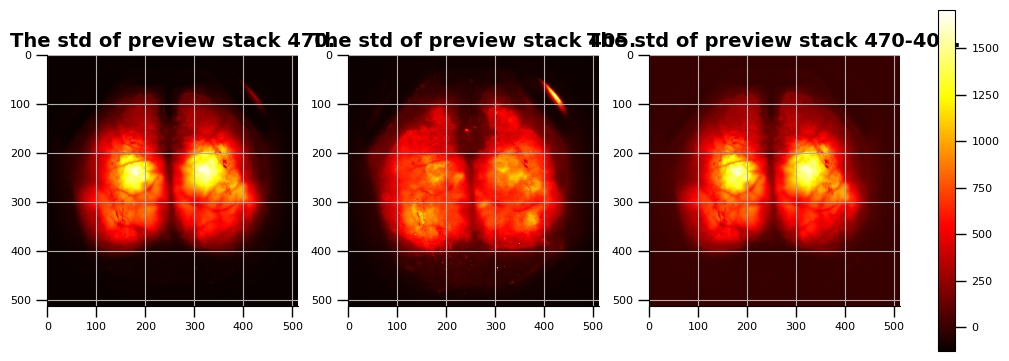

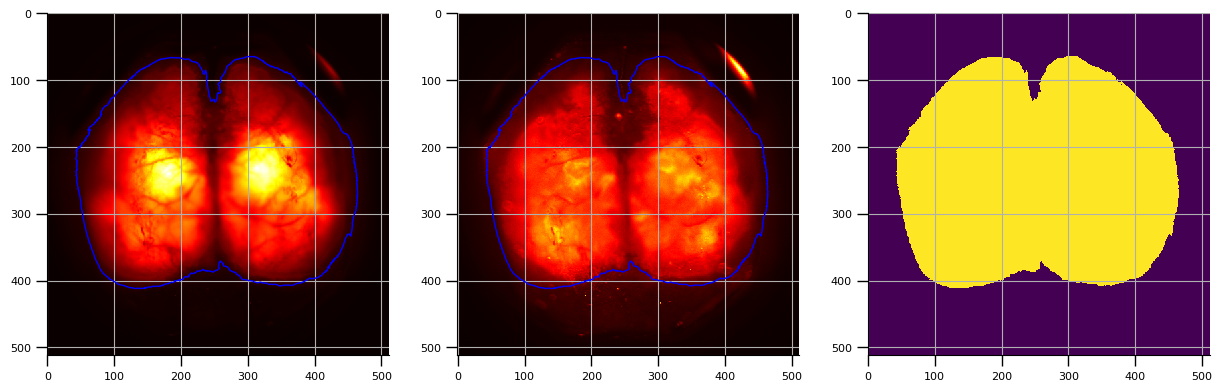

In [5]:
def show_images(images, titles=None, cmap='hot', colorbar=True):
    """
    Display a list of images side by side with a shared colorbar.

    Parameters:
    - images: list of 2D numpy arrays (images to display)
    - titles: list of strings (titles for each image)
    - cmap: string (colormap to use)
    - colorbar: bool (whether to display shared colorbar)
    """
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(10, 4.5), constrained_layout=True)

  
    if n == 1:
        axes = [axes]


    im_objs = []
    for i in range(n):
        im = axes[i].imshow(images[i], cmap=cmap, aspect='equal')
        im_objs.append(im)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('on') 
        axes[i].grid()

    
    if colorbar:
        fig.colorbar(im_objs[-1], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

    plt.show()

for experiment in experiments:    

    plot_test = True

    n_preview = 600
    tiff_list_470 = glob(pjoin(single_day_path, experiment + '*-470/*.tif'))[:n_preview]
    preview_stack_470 = np.array([imread(tiff) for tiff in tiff_list_470])
    tiff_list_405 = glob(pjoin(single_day_path, experiment + '*-405/*.tif'))[:n_preview]
    preview_stack_405 = np.array([imread(tiff) for tiff in tiff_list_405])
    preview_std_470 = np.std(preview_stack_470, axis=0)
    preview_std_405 = np.std(preview_stack_405, axis=0)

    if plot_test:
        images = [preview_std_470, preview_std_405, preview_std_470 - preview_std_405]
        title = ['The std of preview stack 470.', 
                'The std of preview stack 405.', 
                'The std of preview stack 470-405.']
        show_images(images, titles=title, colorbar=True)
        std_level = 100

    contour = measure.find_contours(image=preview_std_470, level=std_level)
    contour_len = [len(_contour) for _contour in contour]
    contour_max = contour[np.argmax(contour_len)]

    mask = np.zeros_like(preview_std_470)
    mask_edge = np.flip(contour_max, axis=1).astype(int)
    mask = cv2.fillPoly(mask, [mask_edge], 1)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    save_path = os.path.join(mergePath, "mask.npy")
    np.save(save_path, mask)


    if plot_test:
        fig, axis = plt.subplots(figsize=(15, 5), nrows=1, ncols=3)
        
        axis[0].imshow(preview_std_470, cmap='hot')
        axis[0].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[0].grid()
        axis[1].imshow(preview_std_405, cmap='hot')
        axis[1].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[1].grid()
        axis[2].imshow(mask)
        axis[2].grid()
        plt.show()

In [6]:
# masked binary file
for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")  
    print(mergePath)
    _ls = os.listdir(mergePath)

    for f in _ls:
        if f.endswith('.bin'):
            old_bin = os.path.join(mergePath, f)
            os.remove(old_bin)
            print(f'>>> Removed old bin file: {old_bin}')
    
    if np.array([_.endswith('.tif') for _ in _ls]).sum() > 1:
        print('!!! There are more than one tif files in the folder, please check the folder!')
    
    tif_stack =  imread(pjoin(mergePath,'*-merged.tif')) 
    tif_stack = tif_stack.astype(np.uint16)# set nchannels=1 for our 2 channel tif file

    mask_path = os.path.join(mergePath, "mask.npy")
    mask = np.load(mask_path)
    masked_stack = tif_stack * mask[None, None, :, :]

    masked_stack = masked_stack.astype(np.uint16)# set nchannels=1 for our 2 channel tif file
    print(masked_stack.shape)
    print('The frames of the stack:', masked_stack.shape[0])
    if masked_stack.shape[0] == 0:
        print('The shape of the stack may be wrong!')

    else: 
        bin_path = pjoin(mergePath, f"{masked_stack.shape[0]}_{masked_stack.shape[1]}_{masked_stack.shape[2]}_{masked_stack.shape[3]}_masked_uint16.bin")
        os.makedirs(os.path.dirname(bin_path), exist_ok=True)
        masked_stack.tofile(bin_path)
        print('Binary file saved:', bin_path)
        
    
print('finish generate binary file.')

/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield
>>> Removed old bin file: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/7644_2_512_512_masked_uint16.bin
>>> Removed old bin file: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/7644_2_512_512_uint16.bin
>>> Removed old bin file: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/7644_2_512_512_uint16_masked.bin
(7644, 2, 512, 512)
The frames of the stack: 7644
Binary file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/7644_2_512_512_masked_uint16.bin
finish generate binary file.


['/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/7644_2_512_512_masked_uint16.bin']


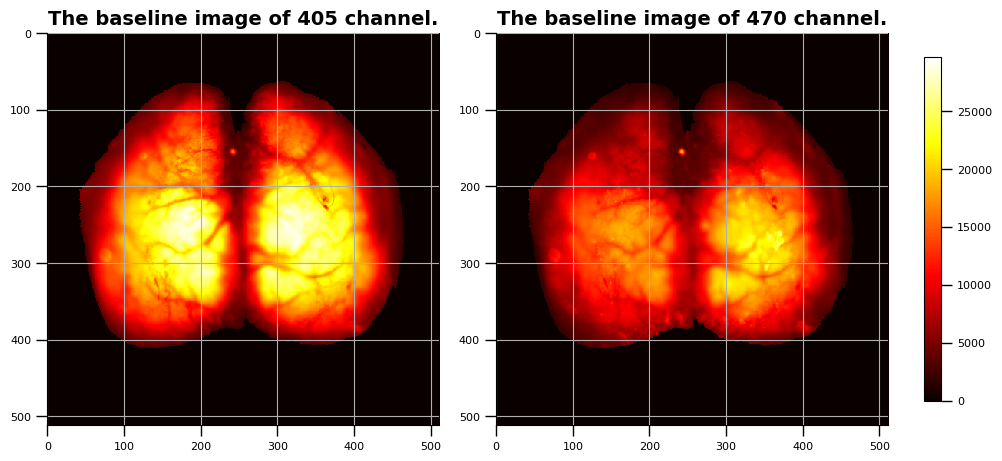

Computing SVT from the raw data: 100%|██████████| 16/16 [00:14<00:00,  1.14it/s]


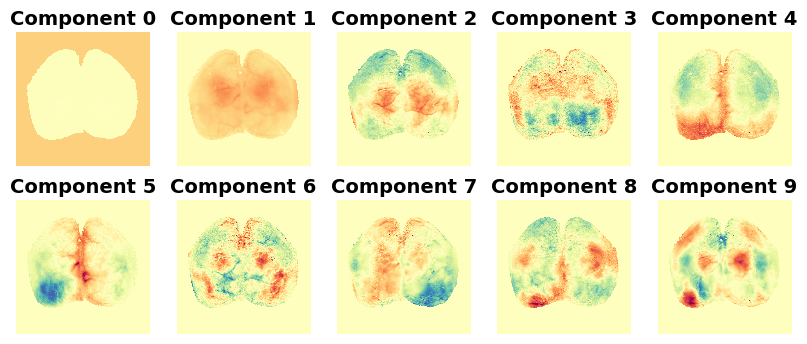

Done hemodynamic correction in 0.018611669540405273 s 


In [9]:
for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")    
    print(glob(pjoin(mergePath, '*uint16.bin')))
    dat = mmap_dat(glob(pjoin(mergePath, '*uint16.bin'))[0])
    # dat = mmap_dat(glob(pjoin(mergePath, '*uint16.bin'))[1])# 多个文件
    image_base_min = np.min(dat[-300:, :, :, :], axis=0)
    np.save(pjoin(mergePath, 'frames_average.npy'), image_base_min)

    if plot_test:
        images = [image_base_min[0], image_base_min[1]]
        title = ['The baseline image of 405 channel.', 'The baseline image of 470 channel.']
        show_images(images, titles=title, colorbar=True)
    
    U, SVT = approximate_svd(dat, image_base_min)

    np.save(pjoin(mergePath,'U.npy'), U)
    np.save(pjoin(mergePath,'SVT.npy'), SVT)

    if plot_test:
        ncomponents = 10
        ncols = 5
        nrows = int(np.ceil(ncomponents/ncols))
        fig = plt.figure(figsize=[2*ncols, 2*nrows])
        for icomponent in range(ncomponents):
            fig.add_subplot(nrows, ncols, icomponent+1)
            plt.imshow(U[:, :, icomponent], clim=[-0.01,0.01],cmap='Spectral_r')
            plt.title('Component {}'.format(icomponent))
            plt.axis('off')
        plt.show()
        
    tstart = time.time()
    fs = 10
    freq_highpass = 0.001
    SVT_470 = SVT[:,0::2]
    t = np.arange(SVT.shape[1]) # interpolate the violet
    from scipy.interpolate import interp1d
    SVT_405 = interp1d(t[1::2], SVT[:,1::2], axis=1,
                        fill_value='extrapolate')(t[0::2])
    # SVTcorr, rcoeffs, T = hemodynamic_correction(U, 
    #                                              SVT_470, 
    #                                              SVT_405, 
    #                                              fs=fs,
    #                                              freq_highpass=freq_highpass,
    #                                              freq_lowpass=10)  

    print('Done hemodynamic correction in {0} s '.format(time.time()-tstart))
    SVTcorr = SVT_470 - SVT_405

    # np.save(pjoin(path,'rcoeffs.npy'), rcoeffs)
    # np.save(pjoin(path,'T.npy'),T)
    np.save(pjoin(mergePath,'SVTcorr.npy'), SVTcorr)


In [10]:
for experiment in experiments:
    mergePath = mergePath = os.path.join(processPath, experiment + "-wfield")    
    merge_file = pjoin(mergePath, experiment+"-merged.tif")
    n_frames = len(TiffFile(merge_file).pages)//2
    
    if os.path.exists(pjoin(single_day_path, experiment + ".csv")):
        if not os.path.exists(pjoin(mergePath, 'trials.csv')):
            stimfile = pd.read_csv(pjoin(single_day_path, experiment + ".csv"), header=None).values
            stim_delay = pd.read_csv(pjoin(single_day_path, experiment + "-470Timestamp.csv"), header=None).values
            stim_delay = int(stim_delay[0]/100)
            n_stimframe = min(stimfile.shape[0]//100-1, n_frames)
            stim = np.zeros(n_stimframe)
            for i in range(n_stimframe):
                stim[i] = stimfile[(i * 100 + stim_delay), 0]
            single_0_indices = np.where((np.diff(np.append(stim, 0)) == 1) & (np.diff(stim, prepend=0) == -1))[0]
            single_1_indices = np.where((np.diff(np.append(stim, 0)) == -1) & (np.diff(stim, prepend=0) == 1))[0]
            stim[single_1_indices] = 0
            stim[single_0_indices] = 1
            
            onset = np.where(np.diff(stim) == 1)[0] + 1
            offset = np.where(np.diff(stim) == -1)[0] + 1
            n_trigger = min(len(onset),len(offset))
            onset = onset[:n_trigger]
            offset = offset[:n_trigger]                
            trials_csv = np.stack((np.arange(len(onset)), onset, offset, offset-onset), axis=1) 
            np.savetxt(pjoin(mergePath, "trials.csv"), trials_csv, delimiter=",")
            print("generate trials.csv of "+experiment)

            trial_onsets = np.stack((np.arange(len(onset)), onset - 30, offset), axis=1)  # retinotopic map stimulus onset time
            np.save(pjoin(mergePath, 'trial_onsets.npy'), trial_onsets)

In [11]:
mergePath_ls = []
for experiment in experiments:
    mergePath =  os.path.join(processPath, experiment + "-wfield")   
    mergePath_ls.append(mergePath)

In [13]:
trials = pd.read_csv(pjoin(mergePath_ls[0], "trials.csv"), header=None, dtype=int).values

In [15]:
mergePath = mergePath_ls[0]

In [16]:
print(mergePath)

/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield


In [17]:
nrepeats = 10
post_trial = 30 # the post trial frames
nframes_el = min(trials[:20, 3]) + post_trial
nframes_az = min(trials[20:40, 3]) + post_trial

In [18]:

U = np.load(pjoin(mergePath, 'U.npy'))
SVTcorr = np.load(pjoin(mergePath, 'SVTcorr.npy'))

nSVD = SVTcorr.shape[0]

# extract trial-data for 4 direction stimuli respectively.
def sort_frames(nframes, *ntrials):
    avg = np.empty((nSVD, 0, nframes))
    raw = np.empty((nSVD, 0))
    for i in ntrials:
        avg = np.concatenate((avg, SVTcorr[:, trials[i, 1]:trials[i, 1] + nframes].reshape(nSVD, 1, nframes)), axis=1)
        raw = np.concatenate((raw, SVTcorr[:, trials[i, 1]:trials[i, 1] + nframes]), axis=1)
    avg = np.mean(avg, axis=1)
    return avg, raw

avg_up, raw_up = sort_frames(nframes_el, *range(nrepeats * 0, nrepeats * 1))
avg_down, raw_down = sort_frames(nframes_el, *range(nrepeats * 1, nrepeats * 2))
avg_left, raw_left = sort_frames(nframes_az, *range(nrepeats * 2, nrepeats * 3))
avg_right, raw_right = sort_frames(nframes_az, *range(nrepeats * 3, nrepeats * 4))

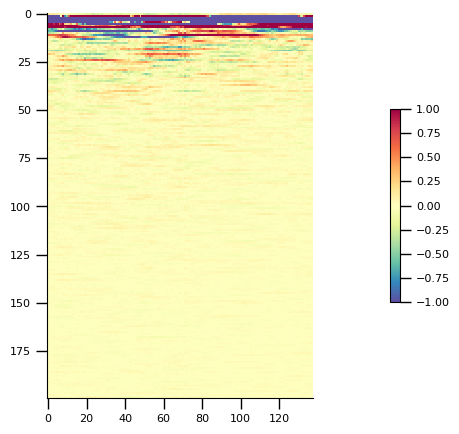

In [19]:
if plot_test:
    fig, ax = plt.subplots(figsize=(20, 5))
    cb = ax.imshow(avg_up, cmap='Spectral_r', clim=[-1, 1]) # 
    fig.colorbar(cb, ax=ax, orientation='vertical', fraction=0.05, shrink=0.5)
    plt.show()

In [20]:
from wfield import im_fftphase_hsv, reconstruct, visual_sign_map

### computes fft in SVD space
component = 10
# from scipy.ndimage import gaussian_filter,median_filter
# mov = runpar(median_filter, U.transpose((2, 0, 1)), size=5)
# U1 = np.stack(mov).transpose((1, 2, 0)).astype(np.float32)
up = reconstruct(U, fft(raw_up.T, axis=0)[component])
down = reconstruct(U, fft(raw_down.T, axis=0)[component])
left = reconstruct(U, fft(raw_left.T, axis=0)[component])
right = reconstruct(U, fft(raw_right.T, axis=0)[component])
phase_el = -1. * (np.angle(up) - np.angle(down))
# phase_el = (phase_el + np.pi) % (2 * np.pi)
phase_el = (phase_el) % (2 * np.pi)
mag_el = (np.abs(up + down) * 2.)

phase_az = -1. * (np.angle(left) - np.angle(right))
# phase_az = (phase_az + np.pi) % (2 * np.pi)
phase_az = (phase_az) % (2 * np.pi)
mag_az = (np.abs(left + right) * 2.)

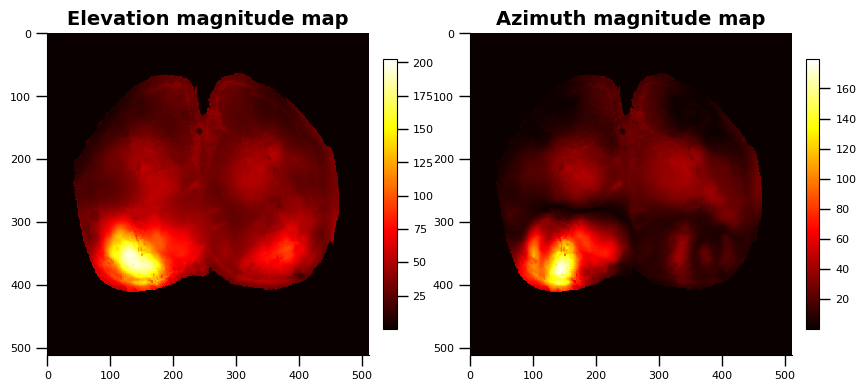

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# cb = axs[0].imshow(np.rot90(mag_el), cmap='hot')
cb = axs[0].imshow(mag_el, cmap='hot')
fig.colorbar(cb, ax=axs[0], fraction=0.046, pad=0.04, shrink=0.7)
axs[0].set_title('Elevation magnitude map')

# cb = axs[1].imshow(np.rot90(mag_az), cmap='hot')
cb = axs[1].imshow(mag_az, cmap='hot')
fig.colorbar(cb, ax=axs[1], fraction=0.046, pad=0.04, shrink=0.7)
axs[1].set_title('Azimuth magnitude map')
plt.show()

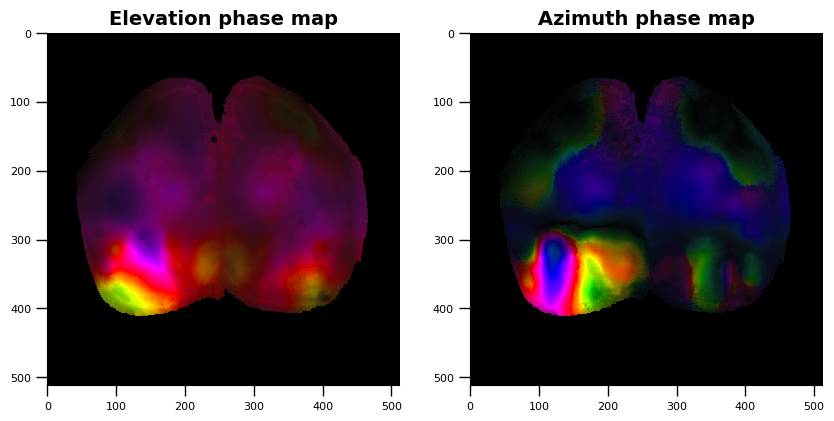

In [22]:
### plot phase maps

# fig = plt.figure(figsize=[10, 5])
fig, axs = plt.subplots(1, 2, figsize=[10, 7])
# fig.add_subplot(1, 2, 1)
# cb = axs[0].imshow(np.rot90(im_fftphase_hsv([mag_el, phase_el], return_hsv=False)))
cb = axs[0].imshow(im_fftphase_hsv([mag_el, phase_el], return_hsv=False))
# plt.axis('off')
# fig.colorbar(cb, ax=axs[0], location='bottom', shrink=0.8)
axs[0].set_title('Elevation phase map')

# axs[1].imshow(np.rot90(im_fftphase_hsv([mag_az, phase_az], return_hsv=False)))
axs[1].imshow(im_fftphase_hsv([mag_az, phase_az], return_hsv=False))
# plt.axis('off')
axs[1].set_title('Azimuth phase map')
fig.set_facecolor('white')
# plt.savefig(pjoin(path_out, 'el_az_unfiltered.png'))
plt.show()

In [23]:
from numpy import unwrap

phase_el_unwrap = unwrap(phase_el, axis=0)  
phase_el_unwrap = unwrap(phase_el_unwrap, axis=1)  

phase_az_unwrap = unwrap(phase_az, axis=0)
phase_az_unwrap = unwrap(phase_az_unwrap, axis=1)


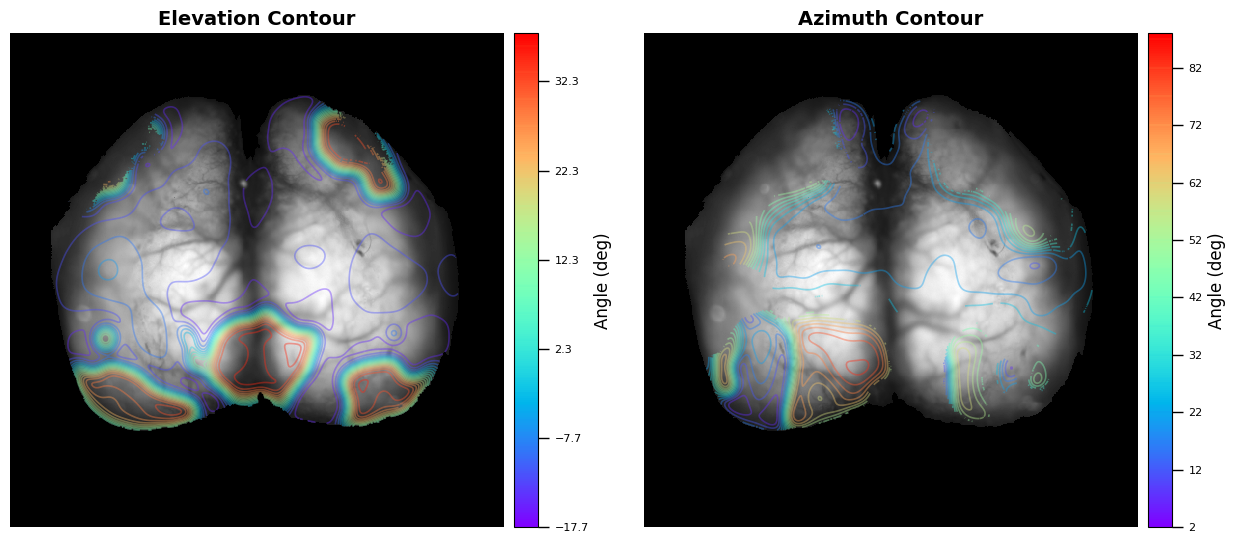

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from wfield import phasemap_to_visual_degrees, im_fftphase_hsv

# ---------- parameters ----------
startdeg_el = -17.7 
stopdeg_el= 37.7
startdeg_az = 2
stopdeg_az= 88
step = 5 
sigma = 7     
mask_threshold = 15 

ref_img = np.load(pjoin(mergePath, "frames_average.npy"))
ref_img = ref_img[0, :, :]  

phase_el_norm = (phase_el % (2*np.pi)) / (2*np.pi)
phase_az_norm = (phase_az % (2*np.pi)) / (2*np.pi)

from scipy.ndimage import gaussian_filter
phase_el_smooth = gaussian_filter(phase_el_norm, sigma=sigma)
phase_az_smooth = gaussian_filter(phase_az_norm, sigma=sigma)


phase_el_smooth[mag_el < mask_threshold] = np.nan
phase_az_smooth[mag_az < mask_threshold] = np.nan


deg_el = phasemap_to_visual_degrees(1-phase_el_smooth, startdeg_el, stopdeg_el)
deg_az = phasemap_to_visual_degrees(1-phase_az_smooth, startdeg_az, stopdeg_az)

fig, axs = plt.subplots(1, 2, figsize=(15, 7))


import numpy as np

# elevation
valid_vals = deg_el[~np.isnan(deg_el)].ravel()
quantiles = np.linspace(0, 1, 20)  # 15条线
levels_el = np.quantile(valid_vals, quantiles)

# azimuth
valid_vals = deg_az[~np.isnan(deg_az)].ravel()
levels_az = np.quantile(valid_vals, quantiles)




ax = axs[0]
X, Y = np.meshgrid(np.arange(deg_el.shape[1]), np.arange(deg_el.shape[0]))
levels = np.arange(startdeg_el, stopdeg_el+3, 3)
# cp = ax.contour(X, Y, deg_el, levels=levels, linewidths=2, cmap='rainbow')
# cp = ax.contour(X, Y, deg_el, levels=levels, linewidths=1, cmap='rainbow', alpha=0.8)
cp = ax.contour(X, Y, deg_el, levels=levels, linewidths=1.2, cmap='rainbow',  alpha=0.4)
ax.set_title('Elevation Contour')
ax.imshow(ref_img, cmap='gray', alpha=1.0)
# ax.imshow(im_fftphase_hsv([mag_el, phase_el], return_hsv=False), alpha=0.6)  
ax.axis('off')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
fig.colorbar(cp, cax=cax, label='Angle (deg)')
from matplotlib.colors import Normalize
norm = Normalize(vmin=startdeg_el, vmax=stopdeg_el)

sm = plt.cm.ScalarMappable(cmap='rainbow', norm=norm)
sm.set_array([])  
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Angle (deg)')


cax.set_yticks(np.arange(startdeg_el, stopdeg_el+1, 10))

# Azimuth

ax = axs[1]
X, Y = np.meshgrid(np.arange(deg_az.shape[1]), np.arange(deg_az.shape[0]))
levels = np.arange(startdeg_az, stopdeg_az+step, step)
cp = ax.contour(X, Y, deg_az, levels=levels, linewidths=1.2, cmap='rainbow', alpha=0.4)
ax.set_title('Azimuth Contour')
ax.imshow(ref_img, cmap='gray', alpha=1.0)
# ax.imshow(im_fftphase_hsv([mag_az, phase_az], return_hsv=False), alpha=0.6) 
ax.axis('off')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
fig.colorbar(cp, cax=cax, label='Angle (deg)')
from matplotlib.colors import Normalize
norm = Normalize(vmin=startdeg_az, vmax=stopdeg_az)

sm = plt.cm.ScalarMappable(cmap='rainbow', norm=norm)
sm.set_array([])  
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Angle (deg)')


cax.set_yticks(np.arange(startdeg_az, stopdeg_az+1, 10))

plt.show()


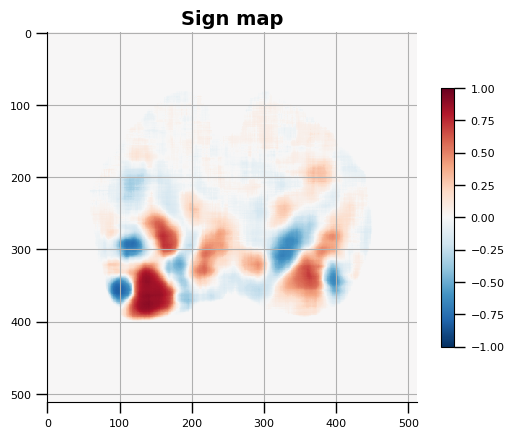

In [25]:
### plot sign maps
from scipy.ndimage import median_filter

sign_map = median_filter(visual_sign_map(phase_az, phase_el), 33)
np.save(pjoin(mergePath, 'sign_map.npy'), sign_map)
fig = plt.figure()

# plt.imshow(np.rot90(sign_map), cmap='RdBu_r', clim=[-1, 1])
plt.imshow(sign_map,
           cmap='RdBu_r', clim=[-1, 1])
plt.grid()
plt.colorbar(shrink=0.7)
x, y = 153, 320
# plt.plot(x, y, 'o', color='black', markersize=5)
# plt.axis('off')
plt.title('Sign map')
fig.set_facecolor('white')
# plt.savefig(pjoin(path_out, 'signmap.png'))
plt.show()

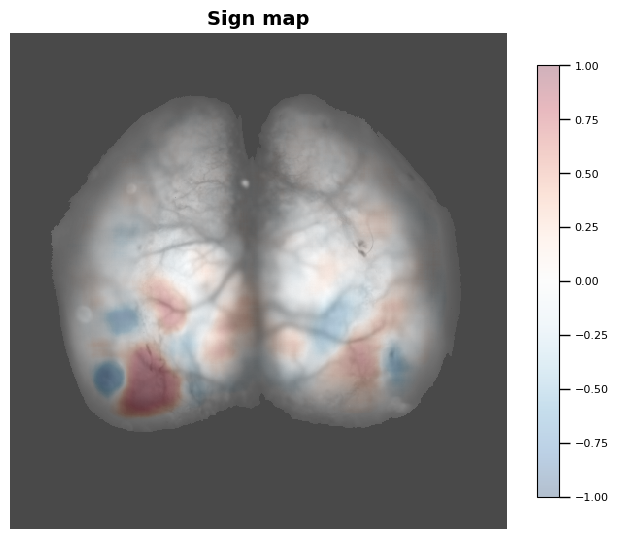

In [26]:
from scipy.ndimage import median_filter

sign_map = median_filter(visual_sign_map(phase_az, phase_el), 33)
np.save(pjoin(mergePath, 'sign_map.npy'), sign_map)

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(ref_img, cmap='gray', alpha=1.0)

im = ax.imshow(sign_map, cmap='RdBu_r', clim=[-1,1], alpha=0.3)

plt.colorbar(im, ax=ax, shrink=0.7)

x, y = 153, 320

ax.set_title('Sign map')
ax.axis('off')
fig.set_facecolor('white')

plt.show()


### CCF alignment

In [27]:
from wfield import *
import pandas as pd

# load data and references
frames_average = np.load(pjoin(mergePath,'frames_average.npy'))
resolution = 0.01248 # mm per pixel
image = frames_average[0] # load a frame from the references 
bregma_offset = (np.array(image.shape[::-1])/2).astype('int')

ccf_regions,proj,brain_outline = allen_load_reference('dorsal_cortex')

# Get or load landmarks, these are for the allen dorsal cortex dataset
landmarks = {'x': [-1.95, 0, 1.95, 0],
             'y': [-3.45, -3.45, -3.45, 3.2],
             'name': ['OB_left', 'OB_center', 'OB_right', 'RSP_base'],
             'color': ['#fc9d03', '#0367fc', '#fc9d03', '#fc4103']}
landmarks = pd.DataFrame(landmarks)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
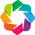

BokehModel(combine_events=True, render_bundle={'docs_json': {'4909389f-e35f-42b5-ad1f-495a6e277199': {'version…

In [30]:
# Load holoviews with the bokeh backend
import holoviews as hv
hv.extension('bokeh')

wid, lmark_wid = hv_adjust_reference_landmarks(landmarks, ccf_regions)
wid


In [ ]:
# load data and references
image = frames_average[0]
lmarks = load_allen_landmarks(None)
landmarks = lmarks['landmarks']
if 'landmarks_match' in lmarks.keys():
    landmarks_match = lmarks['landmarks_match']
else:
    landmarks_match = None
bregma_offset = lmarks['bregma_offset']
resolution = lmarks['resolution']


# The following line lets you plot previous landmarks
# how to load a transform
# landmarks_match = landmarks_match[['x','y','name','color']]

wid,lmark_wid,landmarks_im = hv_adjust_image_landmarks(image, landmarks,
                                                       landmarks_match = landmarks_match,
                                                       bregma_offset = bregma_offset,
                                                       resolution = resolution)
wid

BokehModel(combine_events=True, render_bundle={'docs_json': {'6cc45822-1808-4fac-909a-0d887b331a79': {'version…

In [172]:
landmarks_match = pd.DataFrame(lmark_wid.data)
M = allen_transform_from_landmarks(landmarks_im, landmarks_match)
hv_show_transformed_overlay(frames_average[0], M, ccf_regions,
                            bregma_offset=bregma_offset,
                            resolution=resolution)


:Overlay
   .Image.I       :Image   [x,y]   (z)
   .Curve.I       :Curve   [x]   (y)
   .Curve.II      :Curve   [x]   (y)
   .Curve.III     :Curve   [x]   (y)
   .Curve.IV      :Curve   [x]   (y)
   .Curve.V       :Curve   [x]   (y)
   .Curve.VI      :Curve   [x]   (y)
   .Curve.VII     :Curve   [x]   (y)
   .Curve.VIII    :Curve   [x]   (y)
   .Curve.IX      :Curve   [x]   (y)
   .Curve.X       :Curve   [x]   (y)
   .Curve.XI      :Curve   [x]   (y)
   .Curve.XII     :Curve   [x]   (y)
   .Curve.XIII    :Curve   [x]   (y)
   .Curve.XIV     :Curve   [x]   (y)
   .Curve.XV      :Curve   [x]   (y)
   .Curve.XVI     :Curve   [x]   (y)
   .Curve.XVII    :Curve   [x]   (y)
   .Curve.XVIII   :Curve   [x]   (y)
   .Curve.XIX     :Curve   [x]   (y)
   .Curve.XX      :Curve   [x]   (y)
   .Curve.XXI     :Curve   [x]   (y)
   .Curve.XXII    :Curve   [x]   (y)
   .Curve.XXIII   :Curve   [x]   (y)
   .Curve.XXIV    :Curve   [x]   (y)
   .Curve.XXV     :Curve   [x]   (y)
   .Curve.XXVI    :Curve   [x]   (y)
   .Curve.XXVII   :Curve   [x]   (y)
   .Curve.XXVIII  :Curve   [x]   (y)
   .Curve.XXIX    :Curve   [x]   (y)
   .Curve.XXX     :Curve   [x]   (y)
   .Curve.XXXI    :Curve   [x]   (y)
   .Curve.XXXII   :Curve   [x]   (y)
   .Curve.XXXIII  :Curve   [x]   (y)
   .Curve.XXXIV   :Curve   [x]   (y)
   .Curve.XXXV    :Curve   [x]   (y)
   .Curve.XXXVI   :Curve   [x]   (y)
   .Curve.XXXVII  :Curve   [x]   (y)
   .Curve.XXXVIII :Curve   [x]   (y)
   .Curve.XXXIX   :Curve   [x]   (y)
   .Curve.XL      :Curve   [x]   (y)
   .Curve.XLI     :Curve   [x]   (y)
   .Curve.XLII    :Curve   [x]   (y)
   .Curve.XLIII   :Curve   [x]   (y)
   .Curve.XLIV    :Curve   [x]   (y)
   .Curve.XLV     :Curve   [x]   (y)
   .Curve.XLVI    :Curve   [x]   (y)
   .Curve.XLVII   :Curve   [x]   (y)
   .Curve.XLVIII  :Curve   [x]   (y)
   .Curve.XLIX    :Curve   [x]   (y)
   .Curve.L       :Curve   [x]   (y)
   .Curve.LI      :Curve   [x]   (y)
   .Curve.LII     :Curve   [x]   (y)
   .Curve.LIII    :Curve   [x]   (y)
   .Curve.LIV     :Curve   [x]   (y)
   .Curve.LV      :Curve   [x]   (y)
   .Curve.LVI     :Curve   [x]   (y)
   .Curve.LVII    :Curve   [x]   (y)
   .Curve.LVIII   :Curve   [x]   (y)
   .Curve.LIX     :Curve   [x]   (y)
   .Curve.LX      :Curve   [x]   (y)
   .Curve.LXI     :Curve   [x]   (y)
   .Curve.LXII    :Curve   [x]   (y)
   .Curve.LXIII   :Curve   [x]   (y)
   .Curve.LXIV    :Curve   [x]   (y)
   .Curve.LXV     :Curve   [x]   (y)
   .Curve.LXVI    :Curve   [x]   (y)

In [ ]:
save_allen_landmarks(
    landmarks,
    filename=pjoin(mergePath, 'ccf_transform.json'),
    landmarks_match=landmarks_match,
    transform=M,
    resolution=resolution,
    bregma_offset=bregma_offset
)

In [35]:
lmarks = load_allen_landmarks(pjoin(mergePath, 'ccf_transform.json'))
M = lmarks['transform']
landmarks_im = lmarks['landmarks']
landmarks_match = lmarks['landmarks_match']
resolution = lmarks['resolution']
bregma_offset = lmarks['bregma_offset']
ccf_regions_im = allen_transform_regions(
    M, 
    ccf_regions,
    resolution=resolution,
    bregma_offset=bregma_offset
)


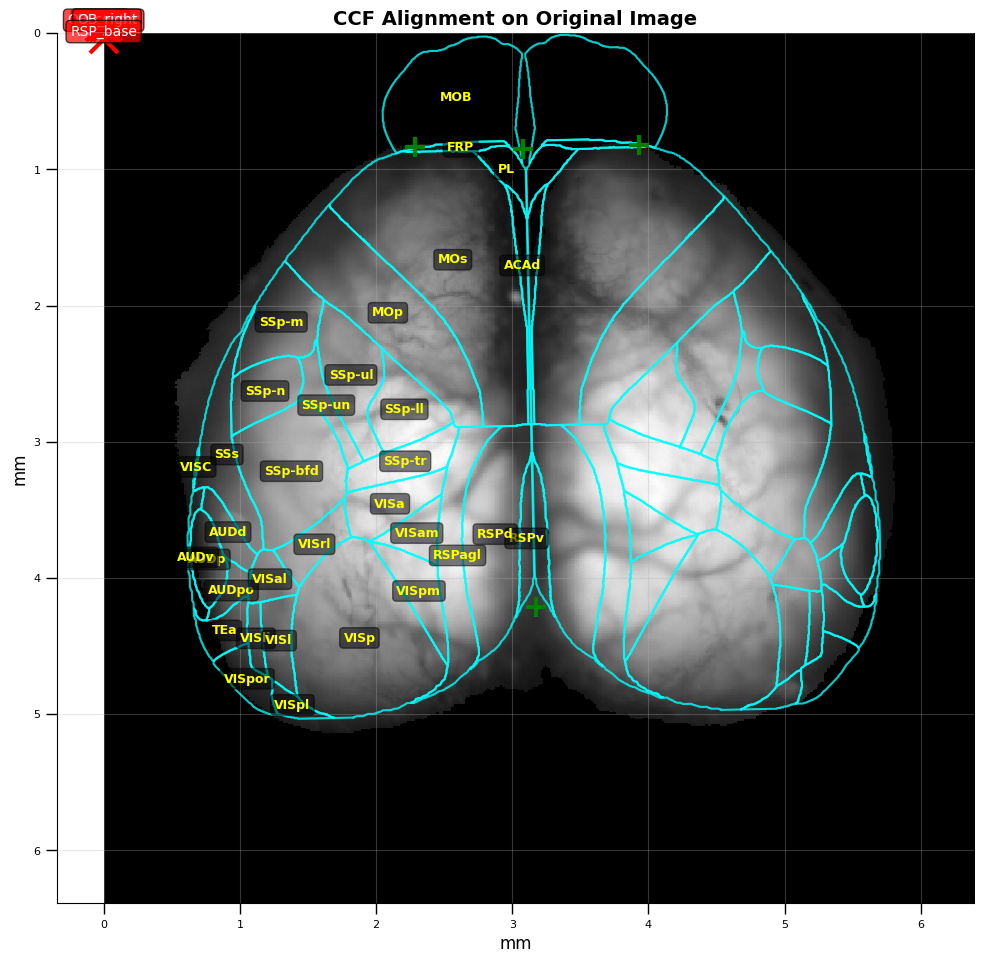

In [37]:
fig1 = plot_alignment_on_original(image, ccf_regions_im, 
                                 landmarks_im, landmarks_match, resolution)
fig1.savefig(pjoin(mergePath, 'ccf_alignment_original.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

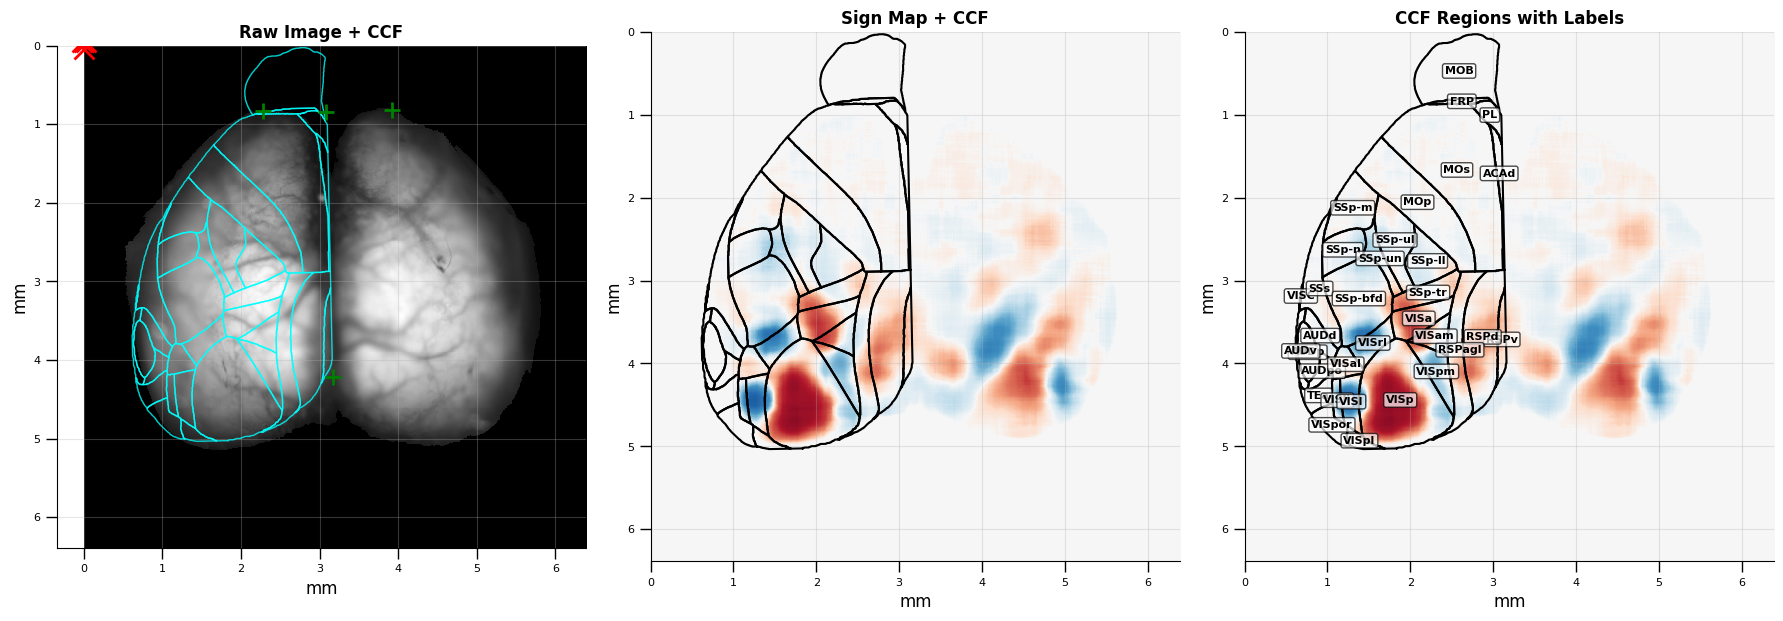

In [39]:
sign_map = np.load(pjoin(mergePath, 'sign_map.npy'))
fig3 = plot_alignment_comparison(image, sign_map, ccf_regions_im,
                                landmarks_im, landmarks_match, resolution)
fig3.savefig(pjoin(mergePath, 'ccf_alignment_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### helper function


In [40]:
def plot_alignment_comparison(image, sign_map, ccf_regions_im, 
                             landmarks_im, landmarks_match,
                             resolution=0.01248):
    """
    多面板对比显示配准结果
    """
    scale = resolution
    h, w = image.shape
    extent = [0, w * scale, h * scale, 0]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
    
    # Panel 1: 原始图像 + CCF + 地标
    axes[0].imshow(image, cmap='gray', extent=extent)
    for i, r in ccf_regions_im.iterrows():
        if 'left_x' in r and r['left_x'] is not None:
            axes[0].plot(np.array(r['left_x']) * scale, 
                        np.array(r['left_y']) * scale,
                        'cyan', lw=1, alpha=0.8)
    for i, r in landmarks_im.iterrows():
        m = landmarks_match.loc[i]
        axes[0].plot(m.x * scale, m.y * scale, 'g+', ms=12, mew=2)
        axes[0].plot(r.x * scale, r.y * scale, 'rx', ms=15, mew=2)
    axes[0].set_title('Raw Image + CCF', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('mm')
    axes[0].set_ylabel('mm')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(bottom=extent[2], top=extent[3])
    
    # Panel 2: Sign map + CCF边界
    axes[1].imshow(sign_map, cmap='RdBu_r', clim=[-1, 1], extent=extent)
    for i, r in ccf_regions_im.iterrows():
        if 'left_x' in r and r['left_x'] is not None:
            axes[1].plot(np.array(r['left_x']) * scale,
                        np.array(r['left_y']) * scale,
                        'black', lw=1.5)
    axes[1].set_title('Sign Map + CCF', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('mm')
    axes[1].set_ylabel('mm')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(bottom=extent[2], top=extent[3])
    
    # Panel 3: CCF区域带标签
    axes[2].imshow(sign_map, cmap='RdBu_r', clim=[-1, 1], extent=extent)
    for i, r in ccf_regions_im.iterrows():
        if 'left_x' in r and r['left_x'] is not None:
            axes[2].plot(np.array(r['left_x']) * scale,
                        np.array(r['left_y']) * scale,
                        'black', lw=1.5)
        name = r['acronym']
        if 'left_center' in r and r['left_center'] is not None:
            left_center = r['left_center']
            axes[2].text(left_center[0] * scale, left_center[1] * scale,
                        name, color='black', ha='center', va='center',
                        fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2',
                                 facecolor='white', alpha=0.7))
    axes[2].set_title('CCF Regions with Labels', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('mm')
    axes[2].set_ylabel('mm')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(bottom=extent[2], top=extent[3])
    
    plt.tight_layout()
    return fig

In [41]:
def plot_alignment_on_original(image, ccf_regions_im, landmarks_im, 
                               landmarks_match, resolution=0.01248):
    """
    在原始图像上叠加CCF区域边界
    
    Parameters:
    -----------
    image : ndarray
        原始宽场图像
    ccf_regions_im : DataFrame
        变换到图像空间的CCF区域
    landmarks_im : DataFrame
        Allen参考地标点
    landmarks_match : DataFrame
        图像上的对应地标点
    resolution : float
        分辨率 (mm/pixel)
    """
    scale = resolution  # mm per pixel
    h, w = image.shape
    extent = [0, w * scale, h * scale, 0]
    
    fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
    
    # 显示原始图像
    ax.imshow(image, cmap='gray', extent=extent)
    
    # 叠加CCF区域边界
    for i, r in ccf_regions_im.iterrows():
        # 左半球
        if 'left_x' in r and r['left_x'] is not None:
            ax.plot(np.array(r['left_x']) * scale, 
                   np.array(r['left_y']) * scale,
                   'cyan', lw=1.5, alpha=0.8)
        # 右半球
        if 'right_x' in r and r['right_x'] is not None:
            ax.plot(np.array(r['right_x']) * scale,
                   np.array(r['right_y']) * scale,
                   'cyan', lw=1.5, alpha=0.8)
    
    # 标注区域名称
    for i, r in ccf_regions_im.iterrows():
        name = r['acronym']
        if 'left_center' in r and r['left_center'] is not None:
            left_center = r['left_center']
            ax.text(left_center[0] * scale, left_center[1] * scale,
                   name, color='yellow', ha='center', va='center', 
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', 
                            facecolor='black', alpha=0.5))
    
    # 显示地标点匹配
    for i, r in landmarks_im.iterrows():
        m = landmarks_match.loc[i]
        # 匹配点 (绿色+)
        ax.plot(m.x * scale, m.y * scale, 'g+', ms=15, mew=3)
        # 参考点 (红色x)
        ax.plot(r.x * scale, r.y * scale, 'rx', ms=20, mew=3)
        # 标签
        ax.text(r.x * scale, r.y * scale, r['name'], 
               color='white', fontsize=10, va='bottom', ha='center',
               bbox=dict(boxstyle='round,pad=0.3', 
                        facecolor='red', alpha=0.7))
    
    ax.set_xlabel('mm', fontsize=12)
    ax.set_ylabel('mm', fontsize=12)
    ax.set_title('CCF Alignment on Original Image', fontsize=14, fontweight='bold')
    ax.set_ylim(bottom=extent[2], top=extent[3])
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig